# **Multiple linear regression model on the california housing dataset:**

Features = all 8(eg. MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude)

Target = MedHouseVal

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

In [2]:
#Load the dataset:
housing = fetch_california_housing()
x = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name = "MedHouseVal")

In [3]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state = 42)

In [4]:
#Train the mltiple linear reg model:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [5]:
#Make predictions
y_pred = model.predict(x_test)

In [6]:
#Evaluate the model:
print("Mean sq error:", mean_squared_error(y_test,y_pred))
print("r2 score:", r2_score(y_test,y_pred))

Mean sq error: 0.5558915986952444
r2 score: 0.5757877060324508


In [7]:
#Interpret the coefficients:
coefficients = pd.DataFrame({"Feature:" : x.columns, "coefficient":model.coef_})
print(coefficients)

     Feature:  coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708


# **Visulaize the model:**

Helps assess how well the predicted prices match actual values.

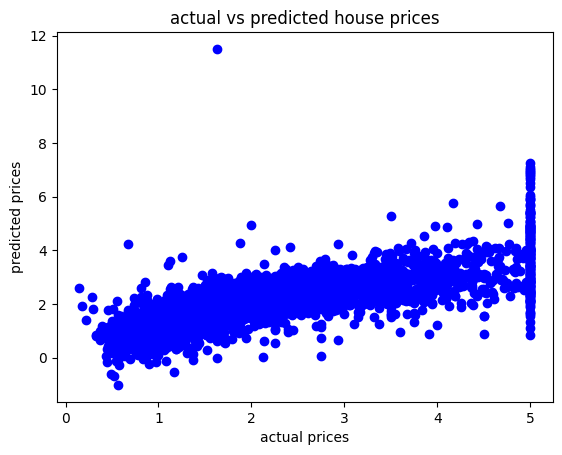

In [8]:
import matplotlib.pyplot as plt

#compare actual vs predicted values.
plt.scatter(y_test,y_pred,color='blue')
plt.xlabel("actual prices")
plt.ylabel("predicted prices")
plt.title("actual vs predicted house prices")
plt.show()


Inference: There's no much increase in the actual & predicted prices.

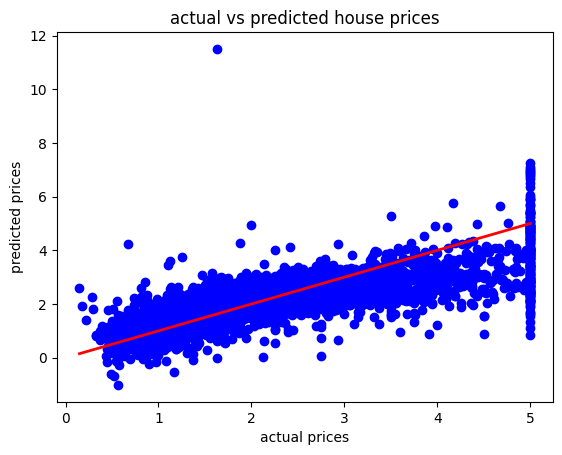

In [9]:
plt.scatter(y_test,y_pred,color='blue')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()], color= 'red',linewidth = 2)
plt.xlabel("actual prices")
plt.ylabel("predicted prices")
plt.title("actual vs predicted house prices")
plt.show()

In [10]:
#Training performance
y_train_pred = model.predict(x_train)
print("Train MSE:", mean_squared_error(y_train,y_train_pred))
print("Train r2:", r2_score(y_train,y_train_pred))

#Testing performance
print("Test MSE:", mean_squared_error(y_test,y_pred))
print("Test r2:", r2_score(y_test,y_pred))

Train MSE: 0.5179331255246699
Train r2: 0.6125511913966952
Test MSE: 0.5558915986952444
Test r2: 0.5757877060324508


**Results interpretation:**


*   The train R-square(0.61) & test R-square(0.58) are quite close.
*   The errors(MSE) are close between train & test
*   There's no big gap between train & test performance. This means your model is not overfitting.

**What this means:**

The model generalizes fairly well. performance is consistent on unseen data.

However the R-square(0.58) indicates the model explains around 58% of the variance in house prices. That's decent, but not very high.

Some non-linear relationships or interactions may not be captured.

## **Conclusion:**

The model is not overfitting.

But it might be a bit underfitting(since linear reg is too simple for housing data)






In [11]:
from sklearn.linear_model import Ridge,Lasso

#Define models
models = {"LR":LinearRegression(),"RR":Ridge(alpha = 1.0),"Lasso Reg":Lasso(alpha=0.01)}

#store results
results = {}
for name,model in models.items():
  model.fit(x_train,y_train)
  y_train_pred = model.predict(x_train)
  y_test_pred = model.predict(x_test)

  results[name] = {
      "train_mse":mean_squared_error(y_train,y_train_pred),
      "train_r2":r2_score(y_train,y_train_pred),
      "test_mse":mean_squared_error(y_test,y_test_pred),
      "test_r2":r2_score(y_test,y_test_pred)
  }

  #show results
  results_df = pd.DataFrame(results).T
  print(results_df)

    train_mse  train_r2  test_mse   test_r2
LR   0.517933  0.612551  0.555892  0.575788
    train_mse  train_r2  test_mse   test_r2
LR   0.517933  0.612551  0.555892  0.575788
RR   0.517933  0.612551  0.555803  0.575855
           train_mse  train_r2  test_mse   test_r2
LR          0.517933  0.612551  0.555892  0.575788
RR          0.517933  0.612551  0.555803  0.575855
Lasso Reg   0.523598  0.608314  0.544449  0.584520


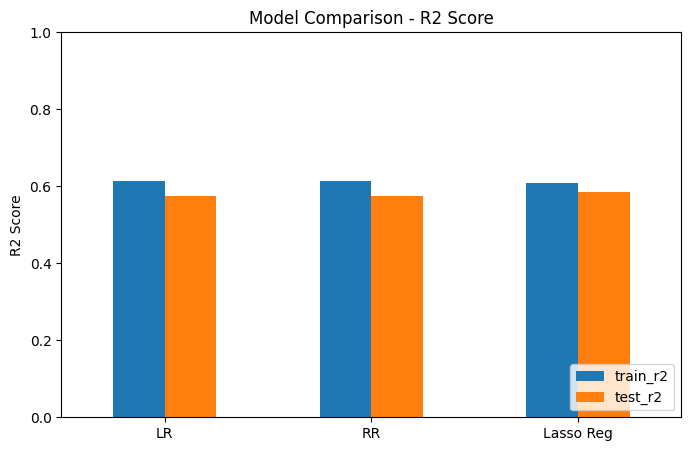

In [12]:
#plot r-square comparison
results_df[["train_r2","test_r2"]].plot(kind = "bar",figsize = (8,5))
plt.title("Model Comparison - R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation = 0)
plt.ylim(0,1)
plt.legend(loc = "lower right")
plt.show()

The taller the test R-square bar, the better the model generalizes.

In [13]:
#fit models
lin_reg = LinearRegression().fit(x_train,y_train)
ridge = Ridge(alpha = 1.0).fit(x_train,y_train)
lasso = Lasso(alpha = 0.01).fit(x_train,y_train)

#collect coefficients
coef_df = pd.DataFrame({"feature":x.columns, "Linear":lin_reg.coef_, "Ridge": ridge.coef_, "Lasso":lasso.coef_})
print(coef_df)

      feature    Linear     Ridge         Lasso
0      MedInc  0.448675  0.448511  4.088956e-01
1    HouseAge  0.009724  0.009726  1.030849e-02
2    AveRooms -0.123323 -0.123014 -4.744454e-02
3   AveBedrms  0.783145  0.781417  3.633460e-01
4  Population -0.000002 -0.000002 -3.086013e-07
5    AveOccup -0.003526 -0.003526 -3.359456e-03
6    Latitude -0.419792 -0.419787 -4.071099e-01
7   Longitude -0.433708 -0.433681 -4.149332e-01


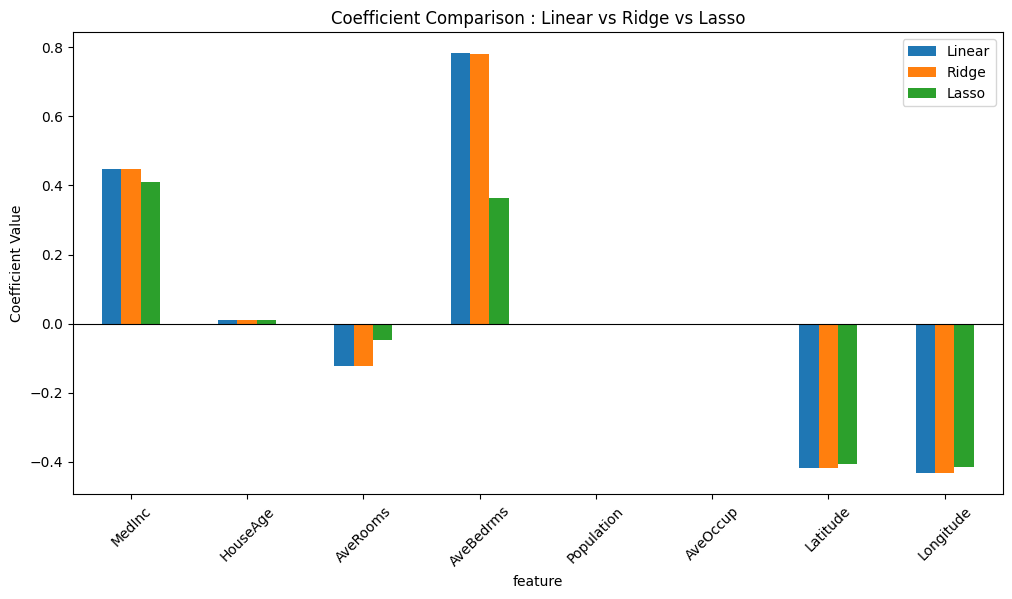

In [14]:
#plot comparison
coef_df.set_index("feature").plot(kind = "bar",figsize = (12,6))
plt.title("Coefficient Comparison : Linear vs Ridge vs Lasso")
plt.ylabel("Coefficient Value")
plt.xticks(rotation = 45)
plt.axhline(0, color = "black", linewidth = 0.8)
plt.legend(loc = "upper right")
plt.show()

**Plot inferences:**

Linear regression: uses all features with their natural coefficients.

Ridge regression: shrinks coef towards 0, but none are eliminated.

Lasso regression: shrinks some coefficients all the way to 0 -> effectively removes those features(automatic feature selection).

**Why your Linear model underfits:**

LR assumes a straight line relationship between features & target.

Housing prices are influenced by non-linear relatonship(eg. income vs price is not perfectly linear).

**Your R-square (0.58) shows the model leaves a lot of variance unexplained**

In [15]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2, include_bias=False)
x_poly = poly.fit_transform(x)

#Train-Test split again on polynomil features.
x_train,x_test,y_train,y_test = train_test_split(x_poly,y,test_size=0.2, random_state = 42)
model = LinearRegression()
model.fit(x_train,y_train)
print("Train r2:", model.score(x_train,y_train))
print("Test r2:", model.score(x_test,y_test))

Train r2: 0.6852681982344968
Test r2: 0.6456819727519338
